# Machine Learning Coursework: Question 3 - Optimization using Genetic Algorithms and MIP

### Setup 

In [26]:
import os
import sys
import pandas as pd
import numpy as np
from IPython.display import Image, display

sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('src'))

# DI stuff
from di.container import AppContainer
container = AppContainer()
# usecase 
data_prep_usecase = container.data_preparation_usecase()
ga_solver_usecase = container.genetic_algorithm_usecase()
mip_solver_usecase = container.mip_solver_usecase()
compare_and_report_usecase = container.compare_and_report_usecase()

## 1 Data Preparation

- 30 IT projects
- Has resource (budget and Developer hrs) constraints
- Has Logical Constrainst (mutual exclusion and interdependant) project

Data is kept at Q3/data directory

In [27]:
instance = data_prep_usecase.execute(num_projects=30, seed=42)

df_proj = pd.DataFrame([
    {"ID": p.id, "Profit ($k)": p.profit, "Cost ($k)": p.cost, "Dev Hours (hours)": p.dev_hours}
    for p in instance.projects
])
display(df_proj.head(10))
print(f"Mutual Exclusion Projects: {instance.mutual_exclusions}")
print(f"Dependeny Projects: {instance.dependencies}")

2026-07-30 09:37:01,228 | INFO     | [ML_CW_Q3] Loaded 30 projects. Total Cost: 2,226.4k, Total Dev Hours: 2,566.5h
2026-07-30 09:37:01,228 | INFO     | [ML_CW_Q3] Organization Capacity: Budget: 1,113.2k, Dev Hours limit: 1,283.3h


,ID,Profit ($k),Cost ($k),Dev Hours (hours)
0,0,161.2,65.6,147.2
1,1,230.0,143.3,53.5
2,2,184.2,113.8,40.3
3,3,194.5,95.8,88.5
4,4,163.0,36.1,158.0
5,5,113.1,36.1,53.9
6,6,108.9,22.8,114.1
7,7,248.6,131.9,126.6
8,8,181.8,96.2,53.3
9,9,215.5,110.6,122.0


Mutual Exclusion Projects: [(3, 7), (12, 18), (22, 27)]
Dependeny Projects: [(8, 2), (15, 10), (25, 20)]


### Project Distribution Plot
Visualize the cost vs profit of 30 projects. The size of the points represents the required developer dev hours.

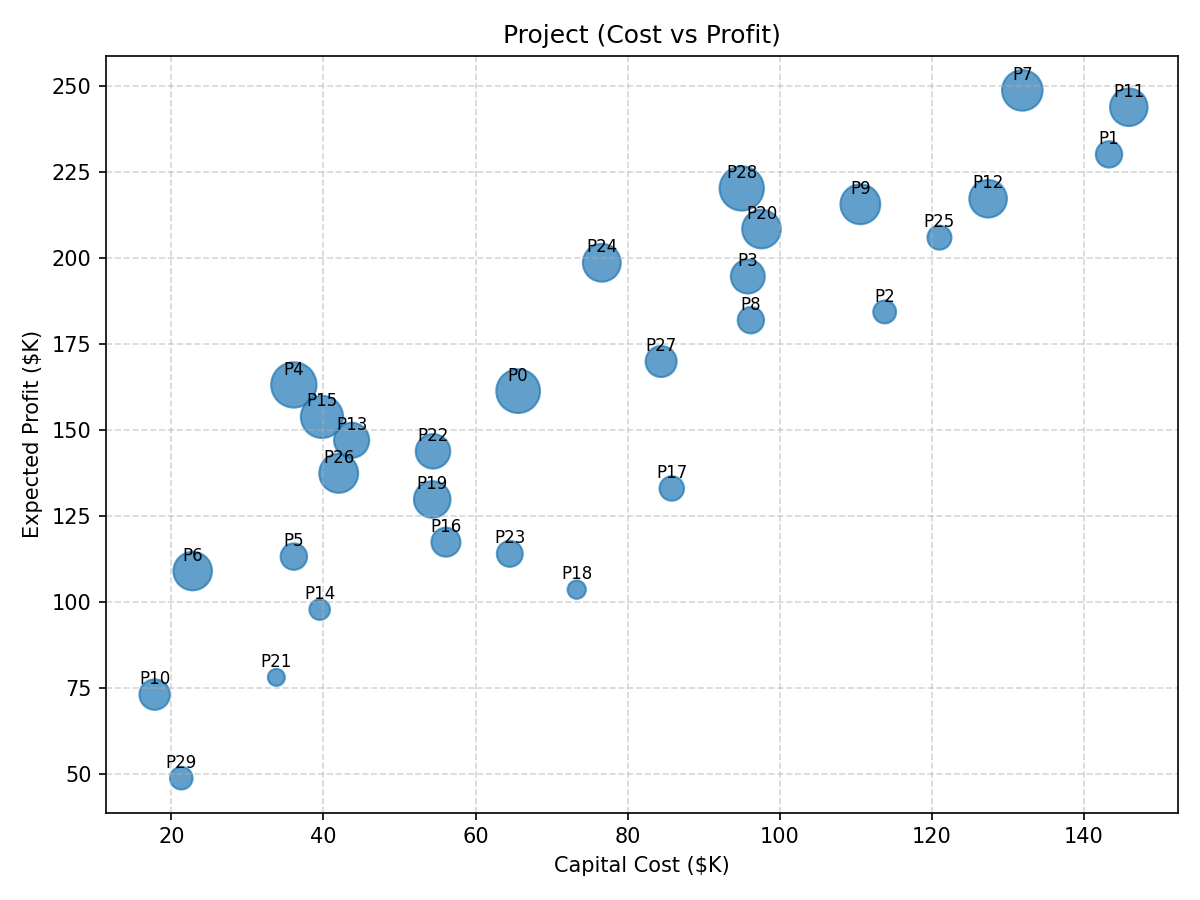

In [28]:
display(Image("plots/project_distribution.png"))

## 2 GA Optimization

Run GA and first tune hyperparameters over different population sizes and generation sizes to find best para mvalues.

In [29]:
# Hyperparameter tuning
tuning_results = ga_solver_usecase.hyperParamTune(instance, pop_sizes=[50, 100, 200, 300], gens=[50, 100, 150, 200])
best_params = tuning_results["best_params"]
print(f"Best Hyperparameters found: {best_params}")

2026-07-30 09:37:01,409 | INFO     | [ML_CW_Q3] GA: pop_size=50, generations=50, mutation_rate=0.0333...
2026-07-30 09:37:01,477 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2450.8k, Feasible: True
2026-07-30 09:37:01,477 | INFO     | [ML_CW_Q3] GA: pop_size=50, generations=100, mutation_rate=0.0333...
2026-07-30 09:37:01,600 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2504.9k, Feasible: True
2026-07-30 09:37:01,601 | INFO     | [ML_CW_Q3] GA: pop_size=50, generations=150, mutation_rate=0.0333...
2026-07-30 09:37:01,786 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2504.9k, Feasible: True
2026-07-30 09:37:01,787 | INFO     | [ML_CW_Q3] GA: pop_size=50, generations=200, mutation_rate=0.0333...
2026-07-30 09:37:02,029 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2485.9k, Feasible: True
2026-07-30 09:37:02,030 | INFO     | [ML_CW_Q3] GA: pop_size=100, generations=50, mutation_rate=0.0333...
2026-07-30 09:37:02,215 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2511.

###  GA Optimization
Run GA with best params (pop size =  100, generations = 50)

In [30]:
ga_solution, history_best = ga_solver_usecase.findBestProjects(
    instance, 
    pop_size=100, 
    generations=50
)

print(f"GA Optimal Profit: ${ga_solution.total_profit:.1f}k")
print(f"Cost: ${ga_solution.total_cost:.1f}k from ${instance.budget:.1f}k")
print(f"Dev Hours: {ga_solution.total_labor:.1f}h from {instance.dev_hours_limit:.1f}h")

2026-07-30 09:37:09,377 | INFO     | [ML_CW_Q3] GA: pop_size=100, generations=50, mutation_rate=0.0333...
2026-07-30 09:37:09,507 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 2511.8k, Feasible: True
GA Optimal Profit: $2511.8k
Cost: $1115.3k from $1113.2k
Dev Hours: 1276.9h from 1283.3h


### GA Best Fitnee and Project Selection Visualization

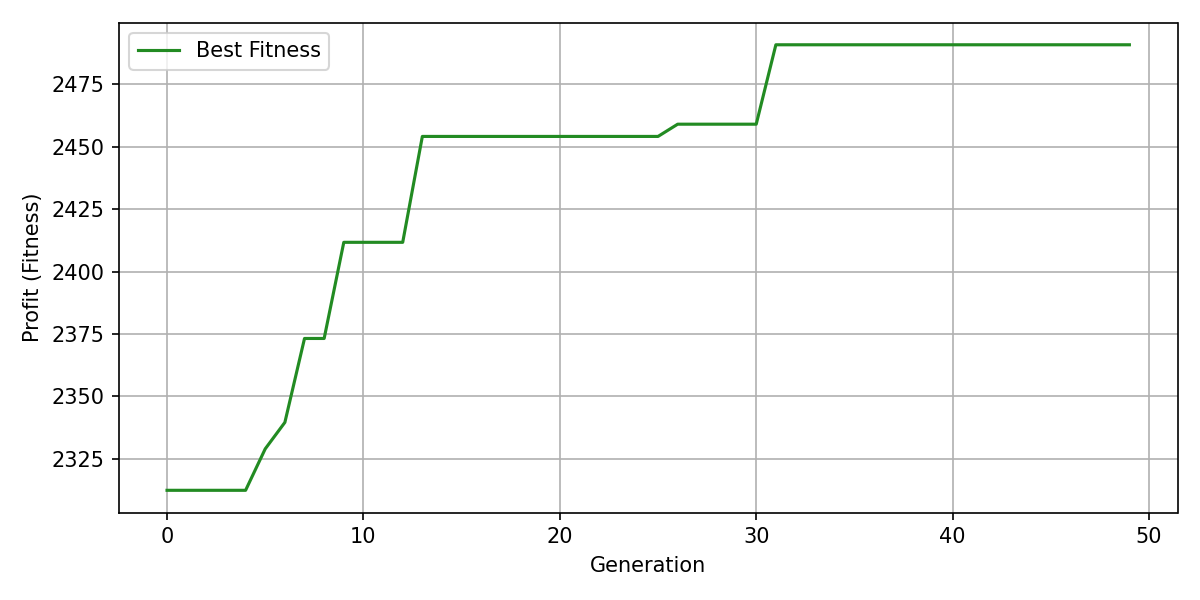

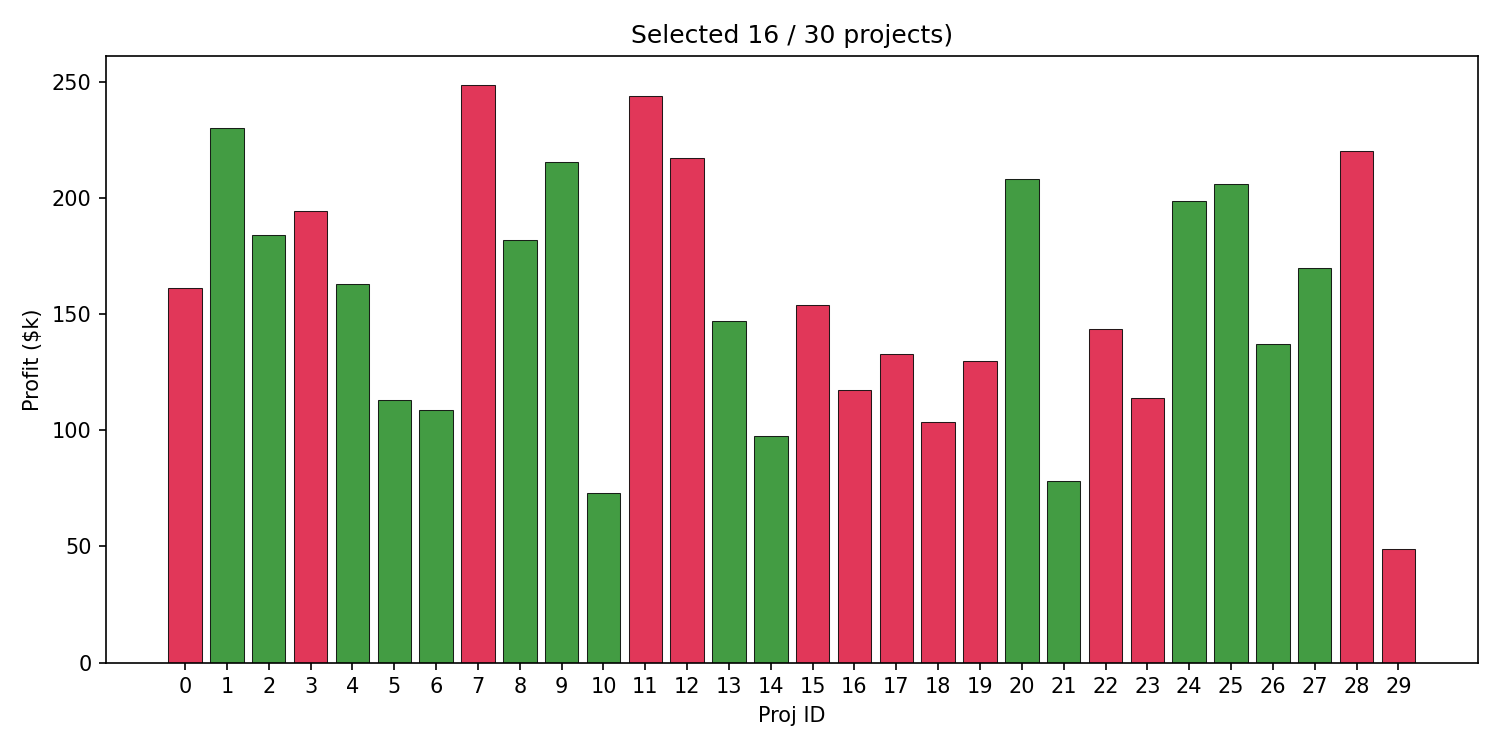

In [31]:
ga_solver_usecase.plot_results(instance, ga_solution, history_best)
display(Image("plots/ga_best_fit.png"))
display(Image("plots/ga_portfolio_selection.png"))

- The best individual is preserved — Best fitness never dropped
- Each 'step' up - discovering a better solution
- Flat - exploring but has not yet found an improvement



## 3 Mixed Integer Programming


In [ ]:
mip_solution, mip_time = mip_solver_usecase.find_best_projects(instance)
print(f"MIP Optimal Profit: ${mip_solution.total_profit:.1f}k")
print(f"Cost: ${mip_solution.total_cost:.1f}k from ${instance.budget:.1f}k")
print(f"Dev Hours: {mip_solution.total_labor:.1f}h from {instance.dev_hours_limit:.1f}h")
print(f"Exec Time: {mip_time:.4f} seconds")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/c3e0f30bc128468f9952ed0f4769ba03-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/c3e0f30bc128468f9952ed0f4769ba03-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 13 COLUMNS
At line 176 RHS
At line 185 BOUNDS
At line 216 ENDATA
Problem MODEL has 8 rows, 30 columns and 72 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 2542.07 - 0.00 seconds
Cgl0004I processed model has 8 rows, 30 columns (30 integer (30 of which binary)) and 72 elements
Cutoff increment increased from 1e-05 to 0.0999
Cbc0038I Initial state - 3 integers unsatisfied sum - 0.9930

/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pulp/pulp.py:1717: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


### Selection Visualizatrion

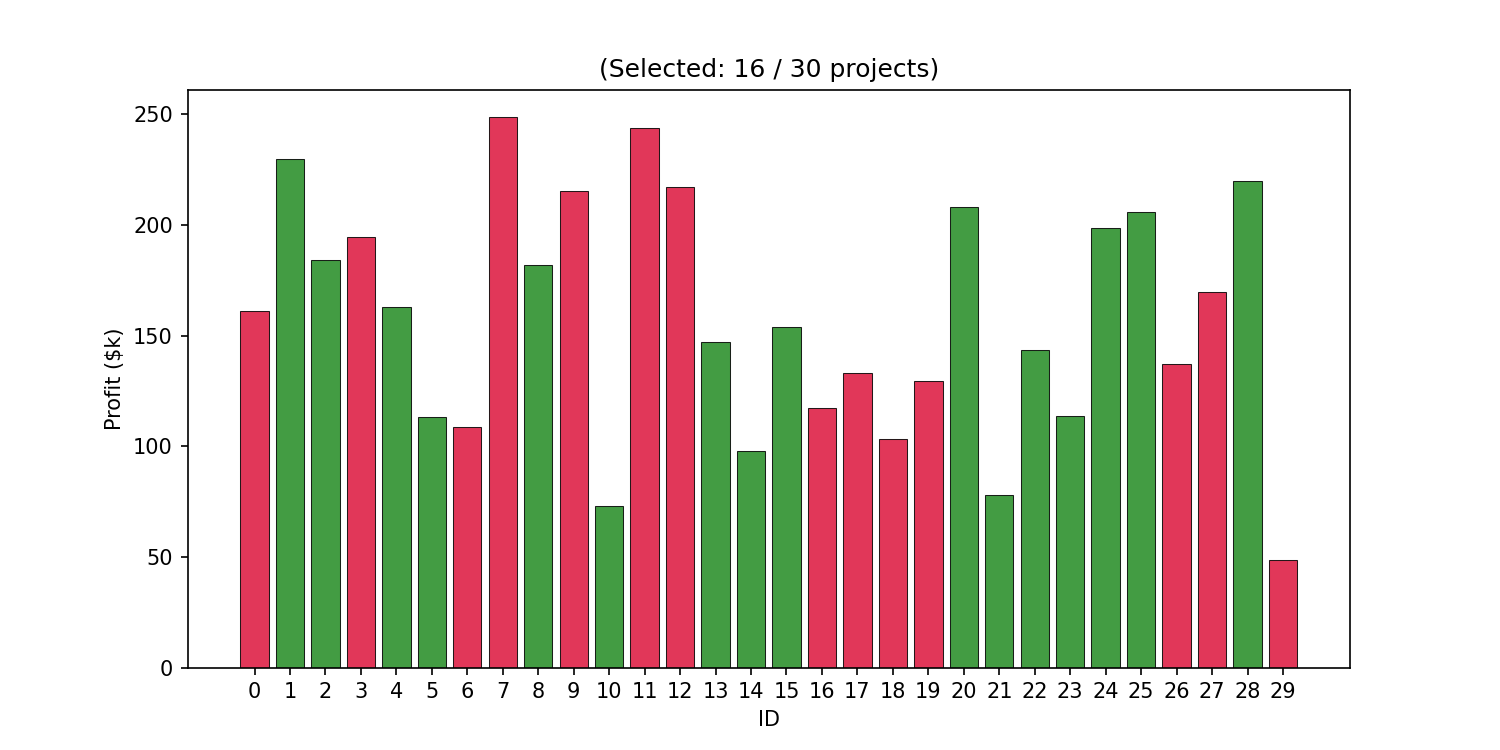

In [8]:
mip_solver_usecase.plot_results(instance, mip_solution)
display(Image("plots/mip_portfolio_selection.png"))

## 4 Comparative Analysis and Critical Reflection

Projects size N = [10, 20, 50, 100, 150, 300, 500, 600, 700, 800, 900, 1000]

In [14]:
scalability_results = compare_and_report_usecase.run_scalability_test(sizes=[10, 20, 50, 100, 150, 300, 500, 600, 700, 800, 900, 1000])
df_scale = pd.DataFrame({
    "Size (N)": scalability_results["sizes"],
    "MIP Time (s)": scalability_results["mip_times"],
    "GA Time (s)": scalability_results["ga_times"],
    "MIP Profit ($k)": scalability_results["mip_profits"],
    "GA Profit ($k)": scalability_results["ga_profits"]
})
display(df_scale)

2026-07-30 09:08:52,974 | INFO     | [ML_CW_Q3] GA vs BIP scalability comparison
2026-07-30 09:08:52,975 | INFO     | [ML_CW_Q3] Testing 10 projects
2026-07-30 09:08:52,978 | INFO     | [ML_CW_Q3] Loaded 10 projects. Total Cost: 852.2k, Total Dev Hours: 957.4h
2026-07-30 09:08:52,978 | INFO     | [ML_CW_Q3] Organization Capacity: Budget: 426.1k, Dev Hours limit: 478.7h
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/bfbae9649b904d24a0eb7136d27f3715-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/bfbae9649b904d24a0eb7136d27f3715-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 9 COLUMNS
At line 64 RHS
At line 69 BOUNDS
At line 80 ENDATA
Problem MODEL has 4 rows, 1

/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pulp/pulp.py:1717: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/769717b7ec8f4230b1960b7874b9feba-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/769717b7ec8f4230b1960b7874b9feba-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 11 COLUMNS
At line 120 RHS
At line 127 BOUNDS
At line 148 ENDATA
Problem MODEL has 6 rows, 20 columns and 48 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 1732.11 - 0.00 seconds
Cgl0004I processed model has 6 rows, 20 columns (20 integer (20 of which binary)) and 48 elements
Cutoff increment increased from 1e-05 to 0.0999
Cbc0038I Initial state - 2 integers unsatisfied sum - 0.4347

/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pulp/pulp.py:1717: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


2026-07-30 09:08:53,661 | INFO     | [ML_CW_Q3] GA Complete. Best Profit: 1699.3k, Feasible: True
2026-07-30 09:08:53,662 | INFO     | [ML_CW_Q3] Testing 50 projects
2026-07-30 09:08:53,664 | INFO     | [ML_CW_Q3] Loaded 50 projects. Total Cost: 3,762.2k, Total Dev Hours: 4,240.0h
2026-07-30 09:08:53,665 | INFO     | [ML_CW_Q3] Organization Capacity: Budget: 1,881.1k, Dev Hours limit: 2,120.0h


...

/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pulp/pulp.py:1717: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/bddda1b2aed54c1f9371208488ee8aca-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/bddda1b2aed54c1f9371208488ee8aca-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 13 COLUMNS
At line 4526 RHS
At line 4535 BOUNDS
At line 5436 ENDATA
Problem MODEL has 8 rows, 900 columns and 1812 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 82180 - 0.00 seconds
Cgl0004I processed model has 8 rows, 900 columns (900 integer (900 of which binary)) and 1812 elements
Cbc0038I Initial state - 2 integers unsatisfied sum - 0.455189
Cbc0038I Pass   1: suminf.    0.2201

/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pulp/pulp.py:1717: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/4b0413ce12d248ac9be791d23c3df76e-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/td/7v2mmkb13sxf8vs73vlh62dh0000gn/T/4b0413ce12d248ac9be791d23c3df76e-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 13 COLUMNS
At line 5026 RHS
At line 5035 BOUNDS
At line 6036 ENDATA
Problem MODEL has 8 rows, 1000 columns and 2012 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 91139.3 - 0.00 seconds
Cgl0004I processed model has 8 rows, 1000 columns (1000 integer (1000 of which binary)) and 2012 elements
Cbc0038I Initial state - 2 integers unsatisfied sum - 0.455156
Cbc0038I Pass   1: suminf.    

,Size (N),MIP Time (s),GA Time (s),MIP Profit ($k),GA Profit ($k)
0,10,0.059265,0.122753,916.1,916.1
1,20,0.088501,0.163581,1699.3,1699.3
2,50,0.324456,0.277208,4249.8,4154.0
3,100,0.459075,0.434462,8688.4,8502.1
4,150,0.503556,0.586141,13270.6,12902.2
5,300,0.509137,1.105392,27206.4,26229.8
6,500,1.799000,1.704883,45563.6,43384.5
7,600,3.284279,2.094505,55116.0,52081.4
8,700,3.694237,2.426100,63782.2,60412.4
9,800,3.589441,2.760198,73081.2,69451.4


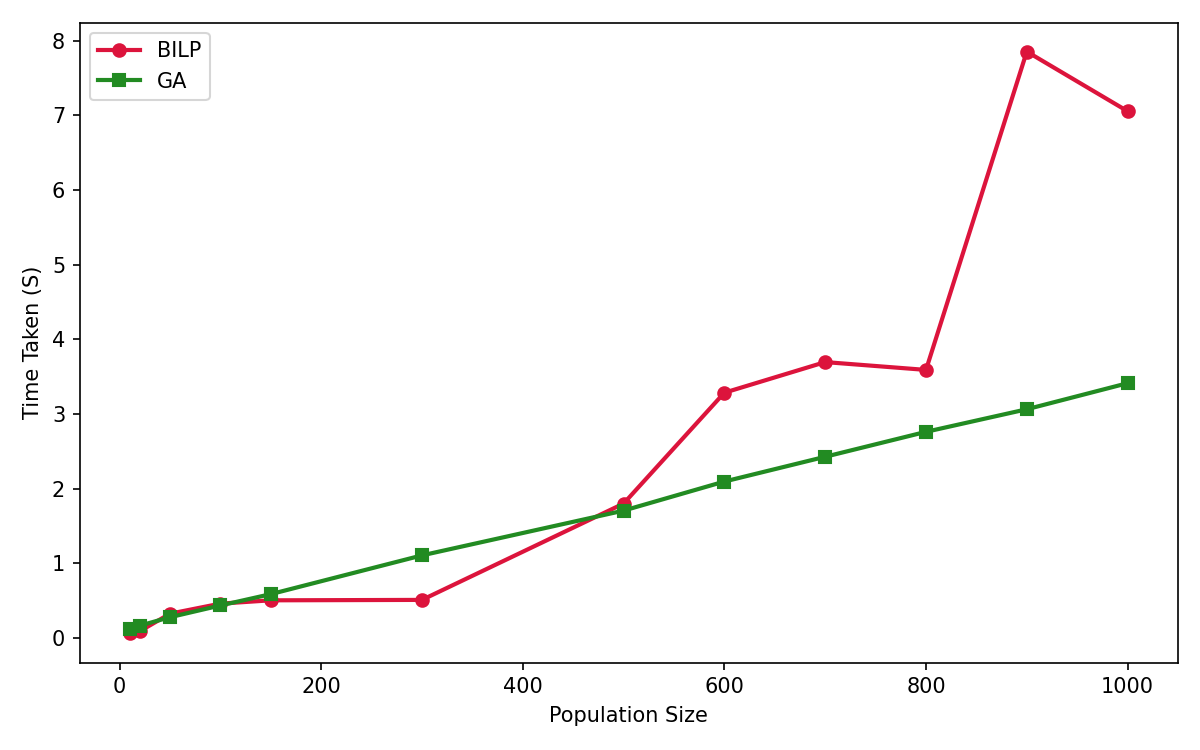

In [15]:
display(Image("plots/ga_bilp_comparison.png"))